# CheXpert Calibration Study
## Research Question
Which uncertainty method best preserves calibration under 
natural distribution shift in chest X-ray diagnosis?

## Hypothesis
I hypothesize that under natural distribution shift in chest X-ray diagnosis — specifically shift caused by scanner and demographic differences across hospitals — post-hoc methods like temperature scaling will fail to preserve calibration because they cannot detect unfamiliar inputs, while deep ensembles will maintain more reliable uncertainty estimates because inter-model disagreement signals distribution shift, and conformal prediction will recover coverage guarantees even when calibration fails, because coverage is guaranteed by construction, not by model confidence

Intro:
CheXpert contains a significant proportion of uncertain labels — cases where radiologists themselves disagreed. A model expressing high confidence on these cases is not just miscalibrated — it is claiming certainty that exceeds expert human judgment. This makes CheXpert an especially honest stress test for uncertainty quantification methods.

Labels missing entirely were excluded from analysis, as they represent undocumented findings rather than confirmed negatives — a distinction with direct implications for calibration measurement.

Limitations:
View type distribution is imbalanced across labels — positives skew frontal, negatives skew lateral — introducing a potential confound between view geometry and pathology signal.

## Experiment Versions
- v1: Data pipeline complete
- v2: Baseline ResNet-50 training (next)

In [14]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ashery/chexpert/valid.csv
/kaggle/input/datasets/ashery/chexpert/train.csv
/kaggle/input/datasets/ashery/chexpert/valid/patient64611/study1/view1_frontal.jpg
/kaggle/input/datasets/ashery/chexpert/valid/patient64545/study1/view1_frontal.jpg
/kaggle/input/datasets/ashery/chexpert/valid/patient64711/study1/view1_frontal.jpg
/kaggle/input/datasets/ashery/chexpert/valid/patient64612/study1/view1_frontal.jpg
/kaggle/input/datasets/ashery/chexpert/valid/patient64684/study1/view1_frontal.jpg
/kaggle/input/datasets/ashery/chexpert/valid/patient64648/study1/view1_frontal.jpg
/kaggle/input/datasets/ashery/chexpert/valid/patient64682/study1/view1_frontal.jpg
/kaggle/input/datasets/ashery/chexpert/valid/patient64587/study1/view1_frontal.jpg
/kaggle/input/datasets/ashery/chexpert/valid/patient64558/study1/view2_lateral.jpg
/kaggle/input/datasets/ashery/chexpert/valid/patient64558/study1/view1_frontal.jpg
/kaggle/input/datasets/ashery/chexpert/valid/patient64717/study1/view1_f

KeyboardInterrupt: 

In [39]:
# Cell — Build Model
import torchvision.models as models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def build_model(pretrained=True):
    model = models.resnet50(weights='IMAGENET1K_V1')
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 1)
    return model

model = build_model(pretrained=True)
model = model.to(device)

print(f"Device: {device}")
print(f"Final layer: {model.fc}")
print(f"Model on GPU: {next(model.parameters()).is_cuda}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 221MB/s]


Device: cuda
Final layer: Linear(in_features=2048, out_features=1, bias=True)
Model on GPU: True


In [40]:
# Cell 2 — Session Verification
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"GPU available: {torch.cuda.is_available()}")
print(f"Device: {device}")

# This will error if any upstream cell wasn't run
try:
    print(f"Model defined: {type(model).__name__}")
    print(f"Train batches: {len(train_loader)}")
    print(f"Val batches: {len(val_loader)}")
    print("\nAll systems ready.")
except NameError as e:
    print(f"Missing variable: {e}")
    print("Run All cells from the top first.")

GPU available: True
Device: cuda
Model defined: ResNet
Train batches: 1520
Val batches: 380

All systems ready.


In [41]:
import os

for dirname, _, filenames in os.walk('/kaggle/input/chexpert-v1.0-small'):
    for filename in filenames[:5]:  # first 5 files only
        print(os.path.join(dirname, filename))
    break  # just top level first

In [42]:
import os

# Project structure
os.makedirs('/kaggle/working/checkpoints', exist_ok=True)
os.makedirs('/kaggle/working/results', exist_ok=True)
os.makedirs('/kaggle/working/figures', exist_ok=True)

print("Project structure ready")

Project structure ready


In [43]:
import pandas as pd

train_df = pd.read_csv(
    '/kaggle/input/datasets/ashery/chexpert/train.csv'
)

valid_df = pd.read_csv(
    '/kaggle/input/datasets/ashery/chexpert/valid.csv'
)

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)
print("\nPleural Effusion value counts:")
print(train_df['Pleural Effusion'].value_counts())

Train shape: (223414, 19)
Valid shape: (234, 19)

Pleural Effusion value counts:
Pleural Effusion
 1.0    86187
 0.0    35396
-1.0    11628
Name: count, dtype: int64


In [44]:
from sklearn.model_selection import train_test_split

# Separate uncertain labels first
train_certain = train_df[train_df['Pleural Effusion'] != -1.0].copy()
train_uncertain = train_df[train_df['Pleural Effusion'] == -1.0].copy()

# Drop any remaining NaN values in the label column
train_certain = train_certain.dropna(subset=['Pleural Effusion'])

print(f"Certain samples after NaN drop: {len(train_certain)}")
print(f"Label distribution:\n{train_certain['Pleural Effusion'].value_counts()}")

# Now stratified split
train_split, val_split = train_test_split(
    train_certain,
    test_size=0.2,
    random_state=42,
    stratify=train_certain['Pleural Effusion'].values  # .values converts to numpy array
)

print(f"\nTrain split: {len(train_split)}")
print(f"Val split: {len(val_split)}")
print(f"\nVal distribution:")
print(val_split['Pleural Effusion'].value_counts(normalize=True).round(3))

Certain samples after NaN drop: 121583
Label distribution:
Pleural Effusion
1.0    86187
0.0    35396
Name: count, dtype: int64

Train split: 97266
Val split: 24317

Val distribution:
Pleural Effusion
1.0    0.709
0.0    0.291
Name: proportion, dtype: float64


In [45]:
transform = transforms.Compose([
    transforms.Resize(256),          # Resize shortest side to 256
    transforms.CenterCrop(224),      # Then crop center to 224x224
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # We'll replace these with CheXpert stats
        std=[0.229, 0.224, 0.225]
    )
])


Label: 0.0
Path: CheXpert-v1.0-small/train/patient09418/study1/view2_lateral.jpg
Full path: /kaggle/input/datasets/ashery/chexpert/train/patient09418/study1/view2_lateral.jpg
Image size: (320, 371)


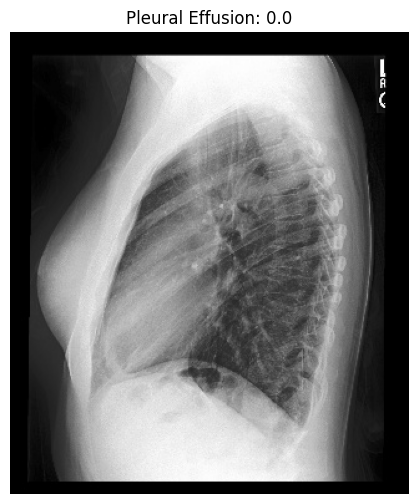

In [46]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Look at one row from your training split
sample_row = train_split.iloc[0]
print("Label:", sample_row['Pleural Effusion'])
print("Path:", sample_row['Path'])

# The paths in CheXpert CSV are relative
# We need to build the full kaggle path
img_path = '/kaggle/input/datasets/ashery/chexpert/' + \
            sample_row['Path'].replace('CheXpert-v1.0-small/', '')

print("Full path:", img_path)

# Load and display
img = Image.open(img_path).convert('RGB')
print("Image size:", img.size)

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='gray')
plt.title(f"Pleural Effusion: {sample_row['Pleural Effusion']}")
plt.axis('off')
plt.show()

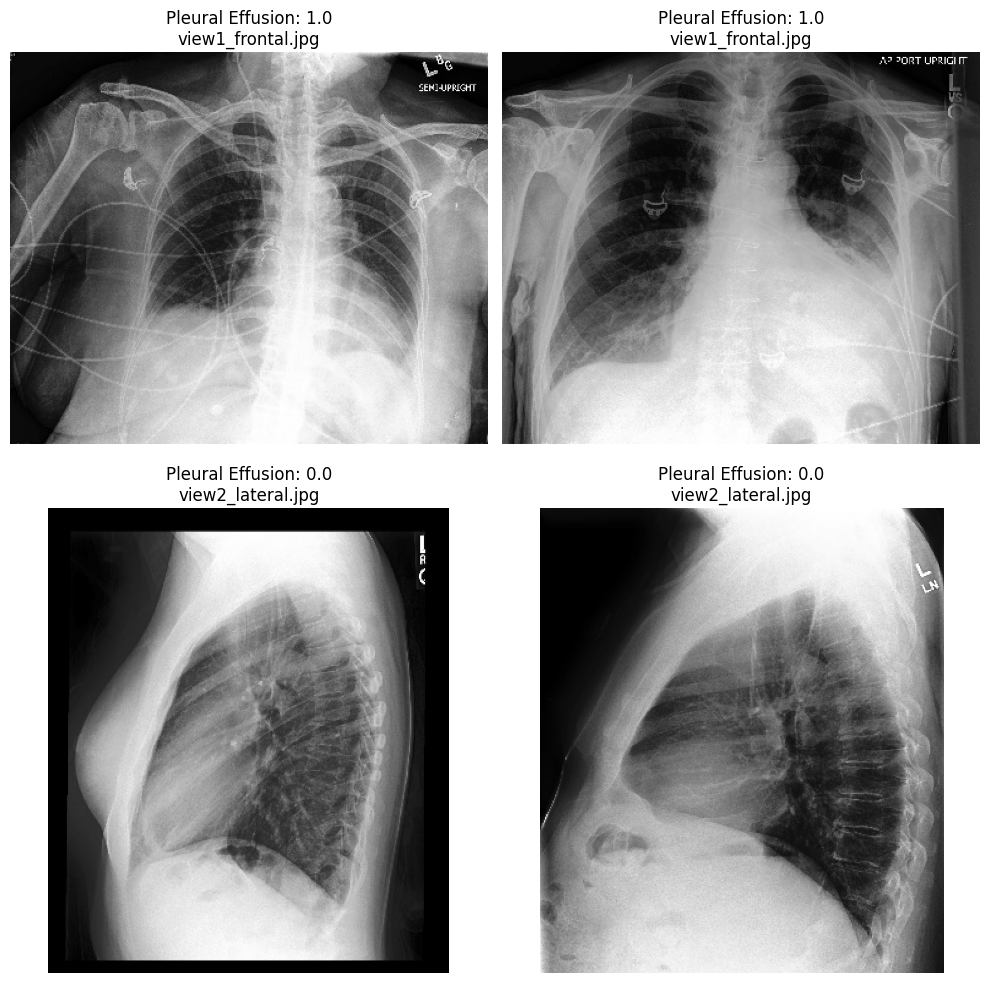

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Get 2 positive and 2 negative samples
positives = train_split[train_split['Pleural Effusion'] == 1.0].head(2)
negatives = train_split[train_split['Pleural Effusion'] == 0.0].head(2)
samples = pd.concat([positives, negatives])

for idx, (ax, (_, row)) in enumerate(zip(axes.flatten(), samples.iterrows())):
    img_path = '/kaggle/input/datasets/ashery/chexpert/' + \
                row['Path'].replace('CheXpert-v1.0-small/', '')
    img = Image.open(img_path).convert('RGB')
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Pleural Effusion: {row['Pleural Effusion']}\n{row['Path'].split('/')[-1]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [48]:
from torch.utils.data import Dataset
from PIL import Image

class CheXpertDataset(Dataset):
    def __init__(self, dataframe, transform=None, base_path=''):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.base_path = base_path

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Build full image path
        img_path = self.base_path + \
                   row['Path'].replace('CheXpert-v1.0-small/', '')
        
        # Load image
        image = Image.open(img_path).convert('RGB')
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        # Get label
        label = torch.tensor(
            row['Pleural Effusion'],
            dtype=torch.float32
        )
        
        return image, label

In [49]:
import torch
from torch.utils.data import DataLoader

BASE_PATH = '/kaggle/input/datasets/ashery/chexpert/'

# Create datasets
train_dataset = CheXpertDataset(
    dataframe=train_split,
    transform=transform,
    base_path=BASE_PATH
)

val_dataset = CheXpertDataset(
    dataframe=val_split,
    transform=transform,
    base_path=BASE_PATH
)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

# Verify one batch
images, labels = next(iter(train_loader))
print(f"\nBatch image shape: {images.shape}")
print(f"Batch label shape: {labels.shape}")
print(f"Label values in batch: {labels.unique()}")

Train batches: 1520
Val batches: 380

Batch image shape: torch.Size([64, 3, 224, 224])
Batch label shape: torch.Size([64])
Label values in batch: tensor([0., 1.])


In [52]:
# Training configuration
EPOCHS = 5
LEARNING_RATE = 1e-4

# Loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(loader):
        # Move to device
        images = images.to(device)
        labels = labels.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(images).squeeze(1)
        
        # Compute loss
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Track metrics
        running_loss += loss.item()
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
        
        # Progress update every 100 batches
        if batch_idx % 100 == 0:
            print(f"  Batch {batch_idx}/{len(loader)} "
                  f"Loss: {loss.item():.4f}")
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images).squeeze(1)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [53]:
# Training history for plotting
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

print("Starting training...")
print(f"Device: {device}")
print(f"Epochs: {EPOCHS}")
print("-" * 50)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    
    # Train
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )
    
    # Evaluate
    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    
    # Save checkpoint
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_loss': val_loss,
    }, f'/kaggle/working/checkpoints/resnet50_epoch{epoch+1}.pth')

print("\nTraining complete.")

Starting training...
Device: cuda
Epochs: 5
--------------------------------------------------

Epoch 1/5
  Batch 0/1520 Loss: 0.4556
  Batch 100/1520 Loss: 0.3415
  Batch 200/1520 Loss: 0.2692
  Batch 300/1520 Loss: 0.1847
  Batch 400/1520 Loss: 0.2195
  Batch 500/1520 Loss: 0.2870
  Batch 600/1520 Loss: 0.2240
  Batch 700/1520 Loss: 0.1727
  Batch 800/1520 Loss: 0.1855
  Batch 900/1520 Loss: 0.2737
  Batch 1000/1520 Loss: 0.2523
  Batch 1100/1520 Loss: 0.3114
  Batch 1200/1520 Loss: 0.2974
  Batch 1300/1520 Loss: 0.3551
  Batch 1400/1520 Loss: 0.1730
  Batch 1500/1520 Loss: 0.2920
  Train Loss: 0.2600 | Train Acc: 0.9009
  Val Loss:   0.2419 | Val Acc:   0.9072

Epoch 2/5
  Batch 0/1520 Loss: 0.2453
  Batch 100/1520 Loss: 0.2950
  Batch 200/1520 Loss: 0.1692
  Batch 300/1520 Loss: 0.2404
  Batch 400/1520 Loss: 0.1375
  Batch 500/1520 Loss: 0.4096
  Batch 600/1520 Loss: 0.1650
  Batch 700/1520 Loss: 0.2659
  Batch 800/1520 Loss: 0.2125
  Batch 900/1520 Loss: 0.2032
  Batch 1000/1520 L

## Training Results — ResNet-50 Baseline
Best checkpoint: Epoch 2 (Val Loss: 0.2366)
Overfitting confirmed from Epoch 3 onward.
Gap at Epoch 5: 0.2539 (train 0.0853 vs val 0.3392)

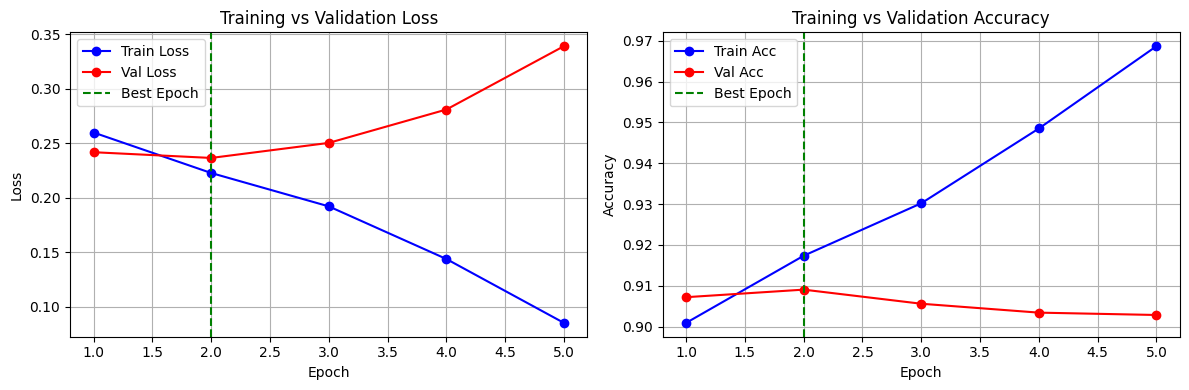

Saved to figures/training_curves.png


In [54]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3, 4, 5]

plt.figure(figsize=(12, 4))

# Loss curves
plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], 
         'b-o', label='Train Loss')
plt.plot(epochs, history['val_loss'], 
         'r-o', label='Val Loss')
plt.axvline(x=2, color='green', 
            linestyle='--', label='Best Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

# Accuracy curves
plt.subplot(1, 2, 2)
plt.plot(epochs, history['train_acc'], 
         'b-o', label='Train Acc')
plt.plot(epochs, history['val_acc'], 
         'r-o', label='Val Acc')
plt.axvline(x=2, color='green', 
            linestyle='--', label='Best Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('/kaggle/working/figures/training_curves.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved to figures/training_curves.png")

In [55]:
# Load best checkpoint
checkpoint = torch.load(
    '/kaggle/working/checkpoints/resnet50_epoch2.pth'
)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"Loaded epoch 2 | Val loss: {checkpoint['val_loss']:.4f}")

# Collect all predictions and labels
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images).squeeze(1)
        probs = torch.sigmoid(outputs)
        
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

import numpy as np
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

print(f"Total predictions: {len(all_probs)}")
print(f"Confidence range: {all_probs.min():.3f} - {all_probs.max():.3f}")
print(f"Mean confidence: {all_probs.mean():.3f}")
print(f"Actual positive rate: {all_labels.mean():.3f}")

Loaded epoch 2 | Val loss: 0.2366
Total predictions: 24317
Confidence range: 0.009 - 1.000
Mean confidence: 0.705
Actual positive rate: 0.709


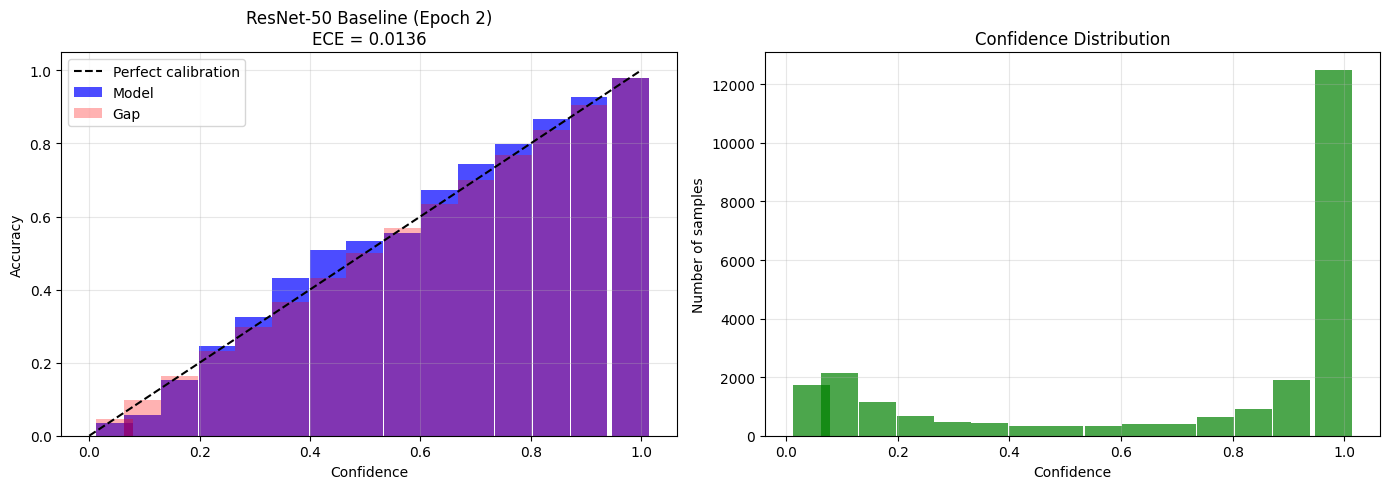


ECE: 0.0136
This means on average, confidence is off by 1.36%


In [57]:
def plot_reliability_diagram(probs, labels, n_bins=15, title='Reliability Diagram'):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    bin_accs = []
    bin_confs = []
    bin_sizes = []
    
    for lower, upper in zip(bin_lowers, bin_uppers):
        # Find predictions in this bin
        in_bin = (probs >= lower) & (probs < upper)
        bin_size = in_bin.sum()
        
        if bin_size > 0:
            bin_acc = labels[in_bin].mean()
            bin_conf = probs[in_bin].mean()
            bin_accs.append(bin_acc)
            bin_confs.append(bin_conf)
            bin_sizes.append(bin_size)
        else:
            bin_accs.append(0)
            bin_confs.append((lower + upper) / 2)
            bin_sizes.append(0)
    
    bin_accs = np.array(bin_accs)
    bin_confs = np.array(bin_confs)
    bin_sizes = np.array(bin_sizes)
    
    # Compute ECE
    ece = np.sum(
        (bin_sizes / len(probs)) * np.abs(bin_accs - bin_confs)
    )
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Reliability diagram
    ax1 = axes[0]
    ax1.plot([0, 1], [0, 1], 'k--', 
             label='Perfect calibration')
    ax1.bar(bin_confs, bin_accs, 
            width=1/n_bins, alpha=0.7, 
            color='blue', label='Model')
    ax1.bar(bin_confs, bin_confs, 
            width=1/n_bins, alpha=0.3, 
            color='red', label='Gap')
    ax1.set_xlabel('Confidence')
    ax1.set_ylabel('Accuracy')
    ax1.set_title(f'{title}\nECE = {ece:.4f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Confidence histogram
    ax2 = axes[1]
    ax2.bar(bin_confs, bin_sizes, 
            width=1/n_bins, alpha=0.7, color='green')
    ax2.set_xlabel('Confidence')
    ax2.set_ylabel('Number of samples')
    ax2.set_title('Confidence Distribution')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/figures/reliability_diagram_baseline.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    
    return ece, bin_accs, bin_confs, bin_sizes

ece, bin_accs, bin_confs, bin_sizes = plot_reliability_diagram(
    all_probs, all_labels,
    title='ResNet-50 Baseline (Epoch 2)'
)

print(f"\nECE: {ece:.4f}")
print(f"This means on average, confidence is off by {ece*100:.2f}%")

## Key Results
- Baseline ECE (in-distribution): 0.0136
- Baseline Val Accuracy: 90.9%
- Baseline Val Loss: 0.2366
- Confidence distribution: Bimodal (peaks near 0 and 1)